### UNet segmentation on pennate diatoms - first attempt
### Rayna Hamilton
### May 1, 2025

We will train a UNet neural network to detect the locations of pennate diatom cells in strained microscopy images.  This cell segmentation approach was first introduced by [Ronnenberger et al., 2015](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28).  I initially planned to apply the  [Duel-Output Unet approach](https://github.com/ToyahJade/DO-U-Net), which addressed the issue of close-together objects by training a network to detect both objects and outlines, then subtracting the outline prediction from the object body prediction.  However, our cells are long and skinny enough that subtracting the outline often makes the whole cell vanish, so I will rely on finding the longest lines within overlapping cells instead.  The ultimate goal of this project is to predict the parasite infection status of each individual cell, but to do this we first need to determine the locations of boundaries of individual cells in the images.

In [1]:
# Read in libraries
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
# %matplotlib inline

from skimage.io import imread, imshow
from skimage.transform import resize

# Don't Show Warning Messages
import warnings
# warnings.filterwarnings('ignore')

IMG_TILE_SIZE=400
IMG_CHANNELS = 3 # RGB


In [2]:
# Read in data
mother_directory = "../../data/train_images/" 
    # home of analyzed output images & csvs
child_directory_image = "ML_output/images/"

if not os.path.isdir(child_directory_image):
    os.mkdir(child_directory_image)

# get a list of files in each folder
mask_dir = "../../data/binary_masks/train/"

img_list = os.listdir(mother_directory)
img_list=[val for val in img_list if val.endswith(".jpg")]
mask_list = os.listdir(mask_dir)
mask_list=[val for val in mask_list if val.endswith(".jpg")]

# create a dataframe
df_images = pd.DataFrame(img_list, columns=['image_id'])

The training data labels are termed binary masks, meaning that all pixels in the image are either 1 (cell) or 0 (non-cell).  

In [3]:
# ================================================
# Add a column indicating if an image has a mask for outline and cell contents
# ================================================

def check_for_mask(x):
    x=x.replace(".jpg",".jpg")
    if x in [val.replace("_masks","") for val in somelist]:
        return 'yes'
    else:
        return 'no'
    
# create a new column called 'has_mask'
somelist=mask_list
df_images['has_mask'] = df_images['image_id'].apply(check_for_mask)
df_images.head()

,image_id,has_mask
0,AS_A_I_15_2-20240718.jpg,yes
1,AS_A_I_15_2-20240724.jpg,yes
2,AS_A_I_15_4-20240720-C28.jpg,yes
3,AS_A_I_22_4-20240718-C15.jpg,yes
4,AS_A_I_22_4-20240722.jpg,yes


In [4]:
df_masks = df_images[df_images['has_mask'] == 'yes']

# create a new column called mask_id that is just a copy of image_id
df_masks['mask_id'] = [val for val in df_masks['image_id']]

df_masks.shape

C:\Users\Rayna\AppData\Local\Temp\ipykernel_194180\2654788443.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_masks['mask_id'] = [val for val in df_masks['image_id']]


(43, 3)

In [5]:
# Get lists of images and their masks.
image_id_list = list(df_masks['image_id'])
mask_id_list = list(df_masks['mask_id'])
# Create empty arrays

X = np.zeros((len(image_id_list), 1040,1388,3), dtype=np.uint8)
y = np.zeros((len(image_id_list), 1040,1388), dtype=bool)
# X_train


for i, image_id in enumerate(image_id_list):
    path_image = mother_directory + image_id
    # read the image using skimage
    image = imread(path_image)
    X[i] = image
    
X.shape

(43, 1040, 1388, 3)

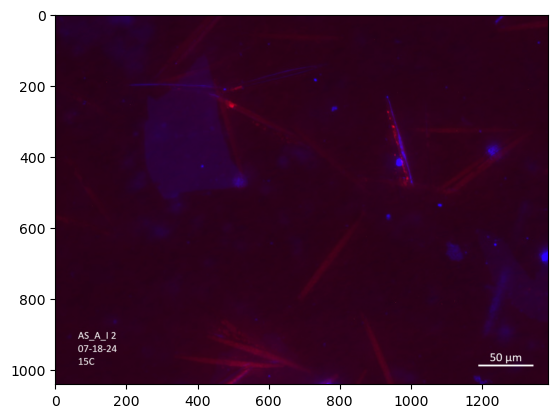

In [6]:
plt.imshow(X[0])

In the above sample image, blue lines are late-stage infected cells, and red lines are healthy cells.

In [7]:
y_cell=[]
for i, mask_id in enumerate(mask_id_list):
    
    path_mask =mask_dir + mask_id
    # read the image using skimage
    mask = imread(path_mask)[:,:,0]
    y_cell.append(mask)
y_cell=np.array(y_cell)
y_cell.shape

(43, 1040, 1388)

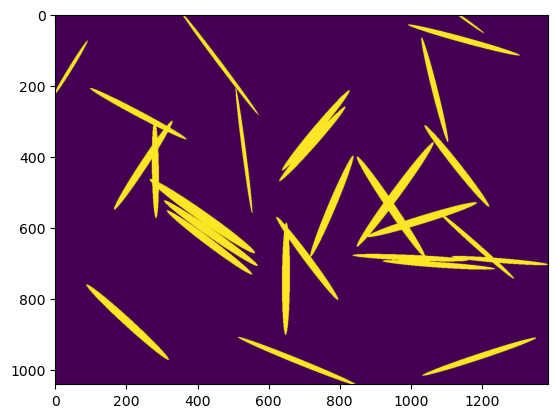

In [8]:
plt.imshow(y_cell[14])

In [9]:
X.shape

(43, 1040, 1388, 3)

Above are examples of the cell binary mask that will be used for training the networks.  Below I am splitting up the images into 400-by-400 pixel chunks, with some overlap between windows to augment our training data.  This is necessary as the network architecture requires square images and is quite picky about dimensions, but I have found that resizing the images results in an undesirable amount of distortion.

In [10]:
tiled_x_cell,tiled_y_cell=[],[]

for i in range(len(X)):
    for y_pos in range(0,900,100):
        for x_pos in range(0,600,100):
            tiled_x_cell.append(X[i,x_pos:x_pos+400,y_pos:y_pos+400])
            tiled_y_cell.append(y_cell[i,x_pos:x_pos+400,y_pos:y_pos+400])

tiled_x_cell,tiled_y_cell=np.array(tiled_x_cell),np.array(tiled_y_cell)

In [11]:
print(tiled_x_cell.shape,tiled_y_cell.shape)

(2322, 400, 400, 3) (2322, 400, 400)


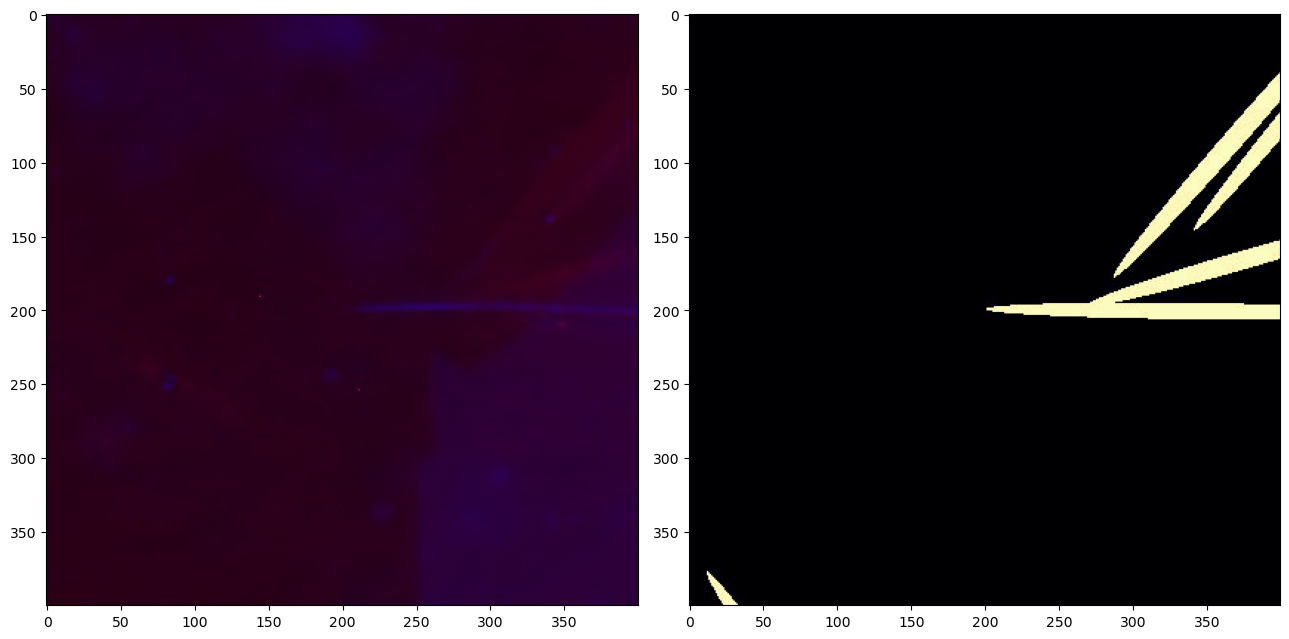

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 10))
ax[0].imshow(tiled_x_cell[0], cmap='magma')
ax[1].imshow(tiled_y_cell[0], cmap='magma')
#ax[0].set_title(image_id_list[0])
#ax[1].set_title(mask_id_list[0])
fig.tight_layout()

Above are examples of the image chunks that were generated by this approach.  We can further augment our otherwise training set by applying rotations and inversions to the images - specifically there are three possible 90 degree rotations and two possible inversions (left-right, up-down).  Some data scientists also play with image intensity and distortion, but I would rather not do that here given the relatively consistent size and shape of the cells.

In [13]:
augmented_X_cell,augmented_y_cell=[],[]

for X,y in zip(tiled_x_cell,tiled_y_cell):
    augmented_X_cell.append(X)
    augmented_y_cell.append(y)

for X,y in zip(tiled_x_cell,tiled_y_cell):
    augmented_X_cell.append(np.rot90(X))
    augmented_y_cell.append(np.rot90(y))

for X,y in zip(tiled_x_cell,tiled_y_cell):
    augmented_X_cell.append(np.fliplr(X))
    augmented_y_cell.append(np.fliplr(y))

for X,y in zip(tiled_x_cell,tiled_y_cell):
    augmented_X_cell.append(np.rot90(X,k=2))
    augmented_y_cell.append(np.rot90(y,k=2))

for X,y in zip(tiled_x_cell,tiled_y_cell):
    augmented_X_cell.append(np.flipud(X))
    augmented_y_cell.append(np.flipud(y))

for X,y in zip(tiled_x_cell,tiled_y_cell):
    augmented_X_cell.append(np.rot90(X,k=3))
    augmented_y_cell.append(np.rot90(y,k=3))


augmented_X_cell,augmented_y_cell=np.array(augmented_X_cell),np.array(augmented_y_cell)
augmented_X_cell.shape

(13932, 400, 400, 3)

In [14]:
augmented_y_cell.shape

(13932, 400, 400)

We now have 14000 training data images to work with.

Now we can define the keras model architecture.  Thanks to [this kaggle notebook](https://www.kaggle.com/code/vbookshelf/simple-cell-segmentation-with-keras-and-u-net) for the sample code used in this step.

In [15]:

from keras.models import Model, load_model
from keras.layers import Input
from keras.layers.core import Dropout, Lambda
from keras.layers.convolutional import Conv2D, Conv2DTranspose
from keras.layers.pooling import MaxPooling2D
from keras.layers import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K

import tensorflow as tf


In [16]:
IMG_CHANNELS=3
inputs = Input((400,400, IMG_CHANNELS))

s = Lambda(lambda x: x / 255) (inputs)

c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (s)
c1 = Dropout(0.1) (c1)
c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c1)
p1 = MaxPooling2D((2, 2)) (c1)

c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p1)
c2 = Dropout(0.1) (c2)
c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c2)
p2 = MaxPooling2D((2, 2)) (c2)

c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p2)
c3 = Dropout(0.2) (c3)
c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c3)
p3 = MaxPooling2D((2, 2)) (c3)

c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p3)
c4 = Dropout(0.2) (c4)
c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c4)
p4 = MaxPooling2D(pool_size=(2, 2)) (c4)

c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p4)
c5 = Dropout(0.3) (c5)
c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c5)

u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same') (c5)
u6 = concatenate([u6, c4])
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u6)
c6 = Dropout(0.2) (c6)
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c6)

u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same') (c6)
u7 = concatenate([u7, c3])
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u7)
c7 = Dropout(0.2) (c7)
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c7)

u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same') (c7)
u8 = concatenate([u8, c2])
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u8)
c8 = Dropout(0.1) (c8)
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c8)

u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same') (c8)
u9 = concatenate([u9, c1], axis=3)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u9)
c9 = Dropout(0.1) (c9)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c9)

outputs = Conv2D(1, (1, 1), activation='sigmoid') (c9)

model = Model(inputs=[inputs], outputs=[outputs])

model.compile(optimizer='adam', loss='binary_crossentropy',loss_weights=[1,1000])

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 400, 400, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda (Lambda)                (None, 400, 400, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 400, 400, 16  448         ['lambda[0][0]']                 
                                )                                                                 
                                                                                              

We must normalize our y data, which currently ranges from 0 to 255, to range from 0 to 1, as otherwise we will encounter issues in loss function calculation.  Then we can train the first model on the cell bodies.  I have allowed for 50 epochs (runs through the entire training data set) though when the model was trained it only ended up running for 43.  While training, we are interested in decreasing the model loss function.  The val_loss refers to loss calculated on the validation set (which is held out in training).  We have also enabled early stopping as neural networks, when allowed to run forever, tend to eventually stop learning meaningful patterns and begin memorizing data images, which results in a worsening of validation loss.  The early stopping functionality makes backups of the model after each epoch, then stops training and reverts to the previous best model as soon as the validation loss begins to worsen.  There is no train-test split being performed in the below data because we have a separate set of imagesthat we will use for this purpose later.  

In [17]:
filepath = "models/cell_model_v2.h5"
from sklearn.model_selection import train_test_split
if not os.path.exists(filepath):
    augmented_y_cell=augmented_y_cell/255
    #X_train, X_test, y_train, y_test = train_test_split(augmented_X_cell, augmented_y_cell, test_size=0.1, random_state=42)
    #augmented_X_cell,augmented_y_cell=[],[]
    earlystopper = EarlyStopping(patience=5, verbose=1)

    checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, 
                                 save_best_only=True, mode='min')
    
    callbacks_list = [earlystopper, checkpoint]
    
    history = model.fit(augmented_X_cell,augmented_y_cell, validation_split=0.1, batch_size=16, epochs=50, 
                    callbacks=callbacks_list)

I will assess testing accuracy and dice score on full testing images in 2_assess_unet.ipynb.